<a href="https://colab.research.google.com/github/pxtroniwnl/analisis-interpersonal-edo-nlp/blob/main/etl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga de Datos

In [2]:
import pandas as pd

# Definimos el separador extraño del dataset de Cornell
SEPARADOR_CORNELL = r' \+\+\+\$\+\+\+ '

# 1. Carga de movie_lines.txt (Contiene el texto de cada frase)
lines = pd.read_csv(
    'movie_lines.txt',
    sep=SEPARADOR_CORNELL,
    names=['lineID', 'characterID', 'movieID', 'characterName', 'text'],
    engine='python',
    encoding='latin-1'
)

# 2. Carga de movie_conversations.txt (Contiene la estructura de los diálogos)
conversations = pd.read_csv(
    'movie_conversations.txt',
    sep=SEPARADOR_CORNELL,
    names=['charID_1', 'charID_2', 'movieID', 'utteranceIDs'],
    engine='python',
    encoding='latin-1'
)

In [3]:
lines

,lineID,characterID,movieID,characterName,text
0,L1045,u0,m0,BIANCA,They do not!
1,L1044,u2,m0,CAMERON,They do to!
2,L985,u0,m0,BIANCA,I hope so.
3,L984,u2,m0,CAMERON,She okay?
4,L925,u0,m0,BIANCA,Let's go.
...,...,...,...,...,...
304708,L666371,u9030,m616,DURNFORD,Lord Chelmsford seems to want me to stay back ...
304709,L666370,u9034,m616,VEREKER,I'm to take the Sikali with the main column to...
304710,L666369,u9030,m616,DURNFORD,"Your orders, Mr Vereker?"
304711,L666257,u9030,m616,DURNFORD,"Good ones, yes, Mr Vereker. Gentlemen who can ..."


In [4]:
conversations

,charID_1,charID_2,movieID,utteranceIDs
0,u0,u2,m0,"['L194', 'L195', 'L196', 'L197']"
1,u0,u2,m0,"['L198', 'L199']"
2,u0,u2,m0,"['L200', 'L201', 'L202', 'L203']"
3,u0,u2,m0,"['L204', 'L205', 'L206']"
4,u0,u2,m0,"['L207', 'L208']"
...,...,...,...,...
83092,u9028,u9031,m616,"['L666324', 'L666325', 'L666326', 'L666327']"
83093,u9028,u9031,m616,"['L666575', 'L666576']"
83094,u9030,u9034,m616,"['L666256', 'L666257']"
83095,u9030,u9034,m616,"['L666369', 'L666370', 'L666371', 'L666372']"


Bueno ya tenemos nuestros datasets cargados pero nuestro objetivo lo que queremos es que estos dialogos y frases pasen a una forma numerica ya que asi como estan ahora no podemos usarlo para la ecuacion diferencial y el modelo de Gotman-Murray ya que lo que entra son numeros con una escala de -1 a 1 donde -1 seria muy malo y 1 muy malo por lo que haremos eso usando una tecnica de **Natural Language Processing (NLP)** llamada **Valence Aware Dictionary and sEntiment Reasoner (VADER)** Usaremos VADER porque esta tecnica tiene en cuenta los terminos coloquiales que se hacen en la pelicula

# VADER

Es una herramienta de análisis de sentimientos diseñada para analizar textos de redes sociales y lenguaje informal. A diferencia de los métodos tradicionales de análisis de sentimientos, es especialmente eficaz para detectar el sentimiento en textos cortos como tuits, reseñas de productos o comentarios de usuarios que contienen jerga, emojis y abreviaturas. Utiliza un léxico predefinido de palabras asociadas a valores de sentimiento y aplica reglas específicas para calcular las puntuaciones de sentimiento.

**VADER** funciona analizando la polaridad de las palabras las cuales a cada una se le asigna una puntuacion que va de -1 a 1 donde esa puntuacion esta asociada al posible sentimiento que quiere inspirar

- Puntuación compuesta > 0,05 : Sentimiento positivo
- Puntuación compuesta < -0,05 : Sentimiento negativo
- Puntuación compuesta entre -0,05 y 0,05 : Sentimiento neutral


In [5]:
!pip install nltk

In [9]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [20]:
sia = SentimentIntensityAnalyzer()

def obtener_humor(texto):
    if pd.isna(texto):
        return 0.0
    score = sia.polarity_scores(texto)
    return score['compound']

Ahora que ya tenemos la funcion para obtener el humor dependiendo de la frase que se ingrese como input de la funcion, y ademas tengo que generar ahora el humor para todas las frases en la columna que tiene las frases

In [21]:
lines["sentimiento"] = lines["text"].apply(obtener_humor)

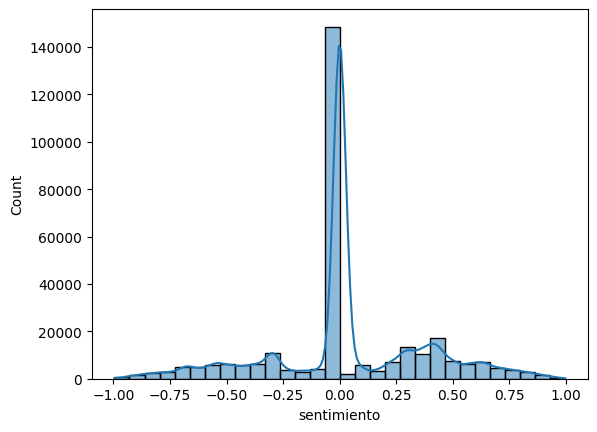

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=lines,x=lines["sentimiento"],bins=30,kde=True)
plt.show()

Vemos que hay muchos datos que tienen una calificacion de 0 por lo que no nos seran muy utiles asi que para interes del proyecto tendremos que buscar otro u modificar ciertas cosas del analizador de sentimientos